# UK House Price Analysis 2024
## A data-driven guide for first-time buyers

This notebook analyses UK Land Registry price paid data to answer two key questions:
1. Which towns and regions are most and least affordable for first-time buyers?
2. Which property types offer the best value?

**Data source:** HM Land Registry Price Paid Data 2024

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# Make plots look clean and professional
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Connect to our database
engine = create_engine("sqlite:///../data/house_prices.db")

print("Ready!")

Ready!


In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

engine = create_engine("sqlite:///../data/house_prices.db")
print("Ready!")

Ready!


In [94]:
df = pd.read_sql("SELECT * FROM transactions", engine)

df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.to_period("M")
df["year"] = df["date"].dt.year

print(f"Loaded {len(df):,} rows")

Loaded 105,248 rows


In [95]:
df_clean = df[
    (df["price"] <= 2_000_000) & 
    (df["year"] == 2025)
].copy()

print(f"2025 transactions: {len(df_clean):,}")

2025 transactions: 79,270


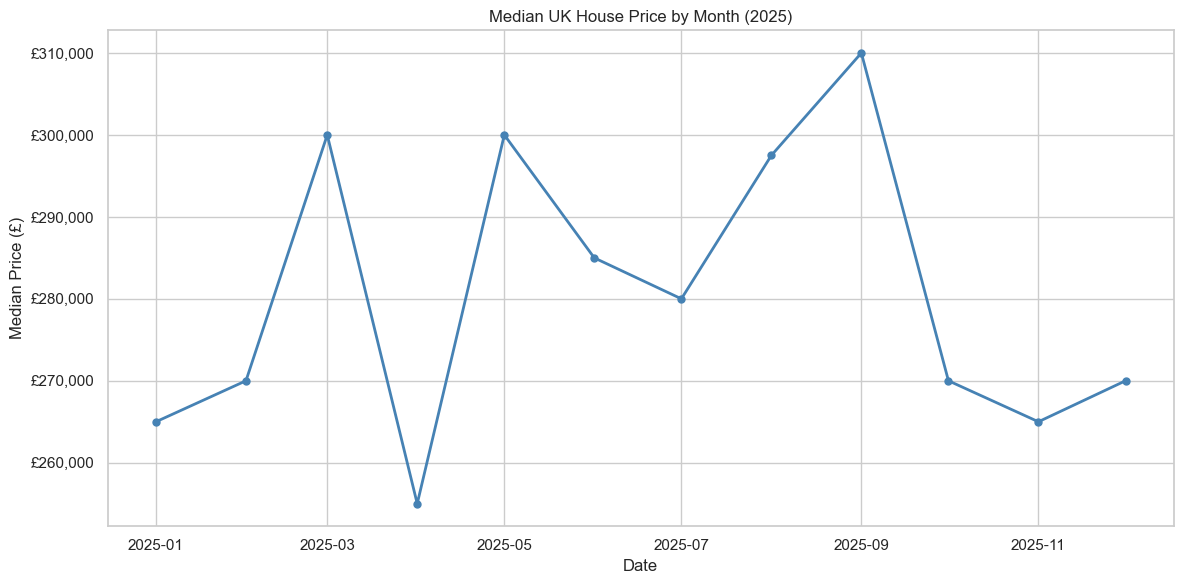

In [96]:
price_over_time = (
    df_clean.groupby("month")["price"]
    .median()
    .reset_index()
)

price_over_time["month"] = price_over_time["month"].dt.to_timestamp()

fig, ax = plt.subplots()

ax.plot(
    price_over_time["month"],
    price_over_time["price"],
    color="steelblue",
    linewidth=2,
    marker="o",
    markersize=5
)

ax.set_xlabel("Date")
ax.set_ylabel("Median Price (£)")
ax.set_title("Median UK House Price by Month (2025)")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"£{x:,.0f}")
)

plt.tight_layout()
plt.show()

In [97]:
print(df_clean.groupby("year")["price"].count().sort_index().tail(10))

year
2025    79270
Name: price, dtype: int64
